In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
from skimage.feature import local_binary_pattern

In [2]:
# Load the Image
image_path = "./Dataset/1.JPG"
img = cv2.imread(image_path)
height, width, channels = img.shape
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
# Step 2: Simulated Near-IR (NIR) Channel using CLAHE
R, G, B = cv2.split(img_rgb)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
nir_sim = clahe.apply(R)
false_color_ir = cv2.merge([nir_sim, G, B])

In [5]:
# Step 3: Facial Landmark Detection using MediaPipe
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
results = None
landmark_coords = []

In [6]:
with mp_face_mesh.FaceMesh(static_image_mode=True) as face_mesh:
    results = face_mesh.process(img_rgb)
    if results.multi_face_landmarks:
        face_landmarks = results.multi_face_landmarks[0]
        for id, lm in enumerate(face_landmarks.landmark):
            x, y = int(lm.x * width), int(lm.y * height)
            landmark_coords.append((id, x, y))

In [8]:
# Step 4: Extract regions - Left Cheek, Right Cheek, Under Eyes
# Approx landmark indices for cheeks and under eyes
regions = {
    "Left Cheek": [234, 93, 132],
    "Right Cheek": [454, 323, 361],
    "Left Under Eye": [145, 159],
    "Right Under Eye": [374, 386]
}

In [9]:
# Step 5: Analyze texture features for each region
def extract_patch_stats(img_gray, points):
    mask = np.zeros(img_gray.shape, dtype=np.uint8)
    for x, y in points:
        cv2.circle(mask, (x, y), 5, 255, -1)
    region = cv2.bitwise_and(img_gray, img_gray, mask=mask)
    mean_intensity = np.mean(region[mask == 255])
    contrast = np.std(region[mask == 255])
    lbp = local_binary_pattern(region, P=8, R=1, method='uniform')
    lbp_mean = np.mean(lbp[mask == 255])
    return mean_intensity, contrast, lbp_mean

In [10]:
# Convert to grayscale for processing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
feature_data = []

for region_name, landmark_ids in regions.items():
    coords = [(x, y) for i, x, y in landmark_coords if i in landmark_ids]
    if coords:
        mean_intensity, contrast, lbp_mean = extract_patch_stats(gray, coords)
        feature_data.append((region_name, mean_intensity, contrast, lbp_mean))

In [11]:
# Step 6: Save feature data to CSV
df_features = pd.DataFrame(feature_data, columns=["Region", "Mean Intensity", "Contrast", "LBP Mean"])
output_csv_path = "./CSVs/facial_region_texture_analysis.csv"
df_features.to_csv(output_csv_path, index=False)

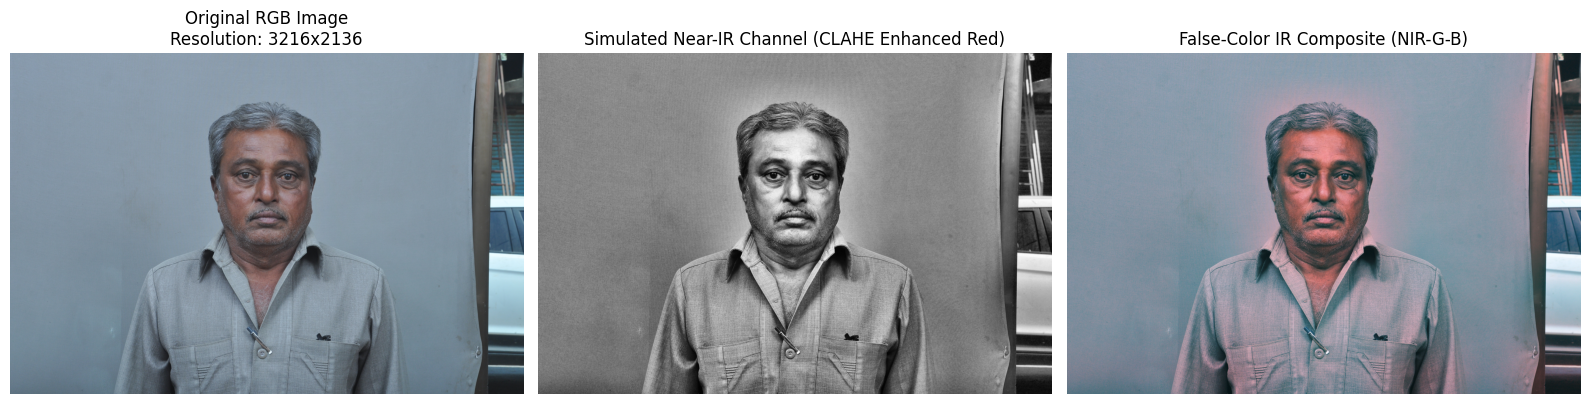

In [12]:
# Step 7: Plot results
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(img_rgb)
axs[0].set_title(f"Original RGB Image\nResolution: {width}x{height}")
axs[0].axis('off')
axs[1].imshow(nir_sim, cmap='gray')
axs[1].set_title("Simulated Near-IR Channel (CLAHE Enhanced Red)")
axs[1].axis('off')
axs[2].imshow(false_color_ir)
axs[2].set_title("False-Color IR Composite (NIR-G-B)")
axs[2].axis('off')
plt.tight_layout()
plt.show()

In [13]:
df_features

,Region,Mean Intensity,Contrast,LBP Mean
0,Left Cheek,101.728395,19.466556,3.806584
1,Right Cheek,86.304527,10.968992,3.934156
2,Left Under Eye,77.771605,34.515925,3.913580
3,Right Under Eye,69.679012,32.546198,4.271605
